# Análise Exploratória de Dados — Spotify Tracks Dataset

**Projeto CBL — Sistemas de Machine Learning**
**Fase:** Investigate

**Objetivo desta etapa:** compreender profundamente o dataset — sua estrutura, qualidade, distribuições e relações entre variáveis — **antes** de decidir a abordagem de modelagem a ser adotada. 

Este notebook é construído em **passos**. Cada seção explica o que está sendo feito e por quê, antes do código.

## Passo 1 — Configuração e carregamento dos dados

Antes de qualquer análise, são necessários três passos:
1. Importação das bibliotecas utilizadas.
2. Carregamento do CSV em um `DataFrame` do pandas (a estrutura de tabela utilizada em toda a análise).
3. Uma primeira inspeção: número de linhas/colunas e amostra dos primeiros registros.

Isso equivale a abrir a planilha e observar seu conteúdo antes de qualquer cálculo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de exibição — só para o notebook ficar mais legível
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../dataset.csv", index_col=0)
print(f"Formato do dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()

Formato do dataset: 114000 linhas x 20 colunas


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Dicionário de dados (fonte oficial)

Antes de seguir com tipos e estatísticas, é importante registrar o significado de cada coluna conforme a documentação oficial do dataset (Hugging Face / Kaggle, *Spotify Tracks Dataset*, coletado via Spotify Web API):

| Coluna | Significado |
|---|---|
| `track_id` | ID da faixa no Spotify |
| `artists` | Artista(s); múltiplos são separados por `;` |
| `album_name` | Nome do álbum em que a faixa aparece |
| `track_name` | Nome da faixa |
| `popularity` | 0–100, calculado por algoritmo com base no volume e recência de execuções. Faixas duplicadas (single vs. álbum) são pontuadas de forma independente |
| `duration_ms` | Duração em milissegundos |
| `explicit` | `True` = letra explícita; **`False` = sem letra explícita OU desconhecido** (os dois casos são indistinguíveis nesta coluna) |
| `danceability` | 0.0–1.0, o quão dançável a faixa é |
| `energy` | 0.0–1.0, intensidade e atividade percebida |
| `key` | Tonalidade em notação de classe de altura padrão (0=C, 1=C♯/D♭, ... 11=B). **Se nenhuma tonalidade foi detectada, o valor é -1** |
| `loudness` | Volume geral em decibéis (dB) |
| `mode` | Modalidade: 1 = maior, 0 = menor |
| `speechiness` | 0.0–1.0, presença de fala; acima de 0.66 = provavelmente só fala |
| `acousticness` | 0.0–1.0, confiança de que a faixa é acústica |
| `instrumentalness` | 0.0–1.0, quanto mais perto de 1.0, maior a chance de não ter vocal |
| `liveness` | 0.0–1.0, presença de plateia; acima de 0.8 sugere gravação ao vivo |
| `valence` | 0.0–1.0, positividade musical (alto = alegre/eufórico, baixo = triste/raivoso) |
| `tempo` | Tempo estimado em BPM |
| `time_signature` | Fórmula de compasso estimada, **documentada como variando de 3 a 7** (3/4 a 7/4) |
| `track_genre` | Gênero da faixa |

Dois pontos da documentação já direcionam checagens específicas feitas no Passo 2 e a seguir:
- `key = -1` é o valor oficial para "nenhuma tonalidade detectada" — precisa ser conferido se ocorre no dataset.
- `time_signature` é documentado como variando **de 3 a 7** — qualquer valor fora dessa faixa (como o `time_signature == 0` já encontrado) está, por definição, fora do domínio documentado.

### Tipos de dado e resumo estatístico

Duas checagens fecham a Pergunta 1 ("como são os dados, estruturalmente?"):

- `df.info()` mostra o **tipo** de cada coluna (número inteiro, decimal, texto, booleano) e quantos valores não-nulos ela tem — já dá uma pista inicial sobre valores ausentes.
- `df.describe()` mostra estatísticas básicas (mínimo, máximo, média, quartis) só das colunas numéricas — é o primeiro sinal de algo estranho, tipo um `duration_ms` igual a 0 ou um `tempo` maior que o fisicamente plausível.

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           114000 non-nu

**Legenda — o que `df.info()` mostra:**

| Coluna da saída | Significado |
|---|---|
| `#` | posição da coluna no DataFrame |
| `Column` | nome da coluna |
| `Non-Null Count` | quantos valores **não estão vazios** nessa coluna (de um total de 114.000 linhas) |
| `Dtype` | o tipo de dado que o pandas atribuiu (`int64` = inteiro, `float64` = decimal, `bool` = verdadeiro/falso, `str` = texto) |

**O que encontramos:**
- Os tipos batem com o esperado: identificação e `track_genre` são texto, `explicit` é booleano, audio features são decimais, o resto é inteiro.
- `artists`, `album_name` e `track_name` têm **113.999** não-nulos (114.000 linhas no total) → **1 linha com valor ausente** nessas 3 colunas. `track_id` e `track_genre` estão 100% preenchidas.
- Nenhuma outra coluna mostra valor ausente por essa checagem — mas isso não significa "sem problema": um `duration_ms = 0`, por exemplo, não é um valor *ausente* (não é nulo), é um valor *preenchido só que inválido*. `info()` não pega esse tipo de erro; é para isso que serve o `describe()` a seguir, e a investigação mais a fundo do Passo 2.

In [3]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


**Legenda — o que `df.describe()` mostra:**

Para cada coluna **numérica**, uma linha de estatísticas:

| Linha | Significado |
|---|---|
| `count` | quantos valores não-nulos existem na coluna |
| `mean` | a média (soma de todos os valores ÷ quantidade) |
| `std` | desvio padrão — o quanto os valores variam em torno da média (maior = mais espalhado) |
| `min` | o menor valor da coluna |
| `25%` | 1º quartil (Q1) — 25% dos valores estão abaixo dele |
| `50%` | mediana (Q2) — o valor do meio; 50% abaixo, 50% acima |
| `75%` | 3º quartil (Q3) — 75% dos valores estão abaixo dele |
| `max` | o maior valor da coluna |

**O que encontramos:**
- Confirmado: `danceability`, `energy`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence` realmente variam de 0 a 1.
- `popularity` varia de 0 a 100 (média ~33 — a maioria das faixas não é hit).
- **Suspeito:** `duration_ms`, `tempo` e `time_signature` têm **mínimo = 0**, o que não é fisicamente possível para uma música real (duração zero, 0 BPM, compasso "0"). Candidatos a erro de coleta, quantificados no Passo 2.
- **Outlier confirmado por IQR:** em `duration_ms`, `Q1=174.066 ms` e `Q3=261.506 ms` → `IQR≈87.440 ms` → limite superior de ~392.666 ms (~6,5 min). O `max` da coluna é **5.237.295 ms (~87 minutos)**, bem acima desse limite — precisa ser investigado (pode ser erro, podcast, ou faixa atípica legítima).

## Passo 2 — Qualidade dos dados: valores ausentes e duplicatas

Após compreender como os dados estão estruturados, esta seção avalia sua confiabilidade. São analisados três pontos, um de cada vez:

1. **Valores ausentes** — onde ocorrem, e qual tratamento é adequado.
2. **Duplicatas** — linhas repetidas, `track_id` repetido, e uma questão levantada na fase de guiding questions: a mesma música aparece múltiplas vezes em gêneros diferentes?
3. Os **zeros suspeitos** identificados em `duration_ms`, `tempo` e `time_signature`.

### 2.1 — Valores ausentes

O resultado de `df.info()` já indicou que `artists`, `album_name` e `track_name` têm 1 valor ausente cada. A seguir, isso é confirmado de forma explícita, com a linha exata exibida.

In [4]:
# Conta valores ausentes por coluna
df.isnull().sum()

track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

In [5]:
# Mostra a(s) linha(s) com valor ausente em qualquer coluna
df[df.isnull().any(axis=1)]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,7,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


### 2.2 — Duplicatas

Três níveis de duplicidade são verificados, do mais estrito ao mais amplo:

1. **Linhas 100% idênticas** (todas as colunas iguais).
2. **`track_id` repetido** — o identificador único do Spotify aparece mais de uma vez.
3. **A mesma música (mesmo nome + mesmo artista) com `track_id` diferente em gêneros diferentes** — hipótese de que o dataset foi construído coletando faixas por gênero, e uma música pode estar catalogada em mais de um gênero simultaneamente.

In [6]:
# 1. Linhas totalmente idênticas
print("Linhas 100% duplicadas:", df.duplicated().sum())

# 2. track_id repetido
print("track_id duplicados:", df['track_id'].duplicated().sum())
print("track_id únicos:", df['track_id'].nunique(), "de", len(df), "linhas")

Linhas 100% duplicadas: 450
track_id duplicados: 24259
track_id únicos: 89741 de 114000 linhas


**Resultado:** 450 linhas totalmente idênticas, e 24.259 ocorrências de `track_id` repetido (89.741 IDs únicos em 114.000 linhas). Esse número é grande demais para ser só erro de coleta pontual — é necessário distinguir dois cenários possíveis:

- **Cenário A:** o mesmo `track_id`, com os mesmos valores em todas as colunas, incluindo `track_genre` → duplicata real (erro de carga/coleta).
- **Cenário B:** o mesmo `track_id`, mas com `track_genre` diferente → a música legitimamente pertence a mais de um gênero no catálogo, e o dataset foi montado coletando faixas gênero por gênero.

A célula a seguir mede, para cada `track_id`, em quantos gêneros distintos ele aparece.

In [7]:
# Para cada track_id, em quantos track_genre distintos ele aparece?
generos_por_track = df.groupby('track_id')['track_genre'].nunique()
generos_por_track.value_counts().sort_index()

track_genre
1    73442
2    11424
3     2955
4     1361
5      431
6      104
7       21
8        2
9        1
Name: count, dtype: int64

**Resultado:** 73.442 `track_id` aparecem em apenas 1 gênero; os demais aparecem em 2 a 9 gêneros diferentes (11.424 em 2 gêneros, 2.955 em 3, e assim por diante). Isso indica o Cenário B como a explicação predominante para a repetição de `track_id`: o catálogo do Spotify classifica a mesma faixa em múltiplos gêneros, e o dataset foi montado coletando por gênero.

A verificação a seguir confirma isso de forma rigorosa: após remover as 450 duplicatas exatas, é comparado, para cada `track_id`, o número de linhas que ele ocupa contra o número de gêneros distintos em que aparece. Se os dois valores forem sempre iguais, toda repetição remanescente é explicada por gênero — não sobra nenhuma duplicata não identificada.

In [8]:
df_sem_dup_exata = df.drop_duplicates()
resumo = df_sem_dup_exata.groupby('track_id')['track_genre'].agg(n_linhas='count', n_generos='nunique')

print("Linhas após remover as 450 duplicatas exatas:", len(df_sem_dup_exata))
print("track_id distintos:", len(resumo))

# Para cada track_id, linhas deveria ser == gêneros distintos (1 linha por gênero, sem sobra)
sobra = resumo[resumo['n_linhas'] > resumo['n_generos']]
print("track_id com repetição NÃO explicada por gênero diferente:", len(sobra))
print("Linhas 'sobrando' nesses casos (duplicata real remanescente):", (sobra['n_linhas'] - sobra['n_generos']).sum())

Linhas após remover as 450 duplicatas exatas: 113550
track_id distintos: 89741
track_id com repetição NÃO explicada por gênero diferente: 0
Linhas 'sobrando' nesses casos (duplicata real remanescente): 0


### 2.3 — Zeros suspeitos em `duration_ms`, `tempo` e `time_signature`

O `describe()` (Passo 1) mostrou valor mínimo igual a 0 nessas três colunas, o que não é fisicamente plausível para uma música real (duração zero, 0 BPM, compasso "0"). A seguir, é quantificado quantas linhas têm cada um desses valores, e se são as mesmas linhas ou problemas independentes.

In [9]:
print("duration_ms == 0:", (df['duration_ms'] == 0).sum())
print("tempo == 0:", (df['tempo'] == 0).sum())
print("time_signature == 0:", (df['time_signature'] == 0).sum())

# As três condições ocorrem nas mesmas linhas, ou são problemas distintos?
mask_qualquer = (df['duration_ms'] == 0) | (df['tempo'] == 0) | (df['time_signature'] == 0)
mask_todas = (df['duration_ms'] == 0) & (df['tempo'] == 0) & (df['time_signature'] == 0)
print()
print("Linhas com pelo menos um desses zeros:", mask_qualquer.sum())
print("Linhas com os três zeros simultaneamente:", mask_todas.sum())

duration_ms == 0: 1
tempo == 0: 157
time_signature == 0: 163

Linhas com pelo menos um desses zeros: 164
Linhas com os três zeros simultaneamente: 0


Nenhuma linha apresenta os três zeros simultaneamente — não se trata de um único registro quebrado se repetindo nas três colunas. `duration_ms == 0` é exatamente a linha de nome ausente já identificada na Seção 2.1. Já `tempo == 0` e `time_signature == 0` são bem mais frequentes e merecem investigação própria: são as mesmas linhas entre si? A que gêneros pertencem?

In [10]:
mask_tempo = df['tempo'] == 0
mask_ts = df['time_signature'] == 0

print("Sobreposição entre tempo==0 e time_signature==0:", (mask_tempo & mask_ts).sum(), "linhas")
print()
print("Distribuição de gênero onde tempo == 0:")
print(df.loc[mask_tempo, 'track_genre'].value_counts().head(10))
print()
print("Distribuição de gênero onde time_signature == 0:")
print(df.loc[mask_ts, 'track_genre'].value_counts().head(10))

Sobreposição entre tempo==0 e time_signature==0: 157 linhas

Distribuição de gênero onde tempo == 0:
track_genre
sleep          138
guitar           4
iranian          4
ambient          3
world-music      3
opera            2
jazz             1
romance          1
show-tunes       1
Name: count, dtype: int64

Distribuição de gênero onde time_signature == 0:
track_genre
sleep          138
guitar           4
iranian          4
ambient          3
opera            3
world-music      3
show-tunes       2
alt-rock         1
disney           1
jazz             1
Name: count, dtype: int64


**Resultado:** as 157 linhas com `tempo == 0` estão totalmente contidas nas 163 com `time_signature == 0` (sobreposição de 157). O gênero `sleep` responde por 138 dessas ocorrências; o restante se concentra em `guitar`, `iranian`, `ambient`, `world-music`, `opera` — gêneros tipicamente sem pulsação rítmica marcada.

Diferente de `duration_ms == 0` (um registro isoladamente quebrado), `tempo == 0` e `time_signature == 0` **não são erro de coleta**: refletem o algoritmo de análise de áudio do Spotify não conseguindo detectar tempo/compasso em faixas de fato arrítmicas. É um valor legítimo — a informação em si ("sem tempo detectável") é relevante para análises futuras — e não deve ser removido ou tratado como ausente.

### 2.4 — Conferindo contra o dicionário de dados

A documentação oficial (Seção "Dicionário de dados") especifica dois pontos que ainda não foram checados:

- `key = -1` é o valor oficial para "nenhuma tonalidade detectada".
- `time_signature` é documentado como variando **de 3 a 7** — o valor `0` já encontrado está fora dessa faixa, mas é necessário confirmar se **outros valores fora do intervalo documentado** também existem.

In [11]:
print("Linhas com key == -1:", (df['key'] == -1).sum())
print()
print("Distribuição completa de time_signature:")
print(df['time_signature'].value_counts().sort_index())

Linhas com key == -1: 0

Distribuição completa de time_signature:
time_signature
0       163
1       973
3      9195
4    101843
5      1826
Name: count, dtype: int64


**Resultado:** não há nenhuma linha com `key == -1` neste dataset — a coluna `key` está sempre preenchida com uma tonalidade real (0 a 11), sem necessidade de tratamento especial.

Já `time_signature` revela um caso adicional: além das 163 linhas com valor `0`, existem **973 linhas com valor `1`** — também fora da faixa documentada (3 a 7). Como esse valor não tinha sido isolado antes (a checagem anterior olhou só o mínimo do `describe()`), ele precisa da mesma investigação de contexto feita para o `tempo == 0`.

In [12]:
mask_ts1 = df['time_signature'] == 1

print("tempo == 0 dentro desse grupo:", ((df['tempo'] == 0) & mask_ts1).sum())
print()
print("Distribuição de tempo onde time_signature == 1:")
print(df.loc[mask_ts1, 'tempo'].describe())
print()
print("Top gêneros onde time_signature == 1:")
print(df.loc[mask_ts1, 'track_genre'].value_counts().head(10))

tempo == 0 dentro desse grupo: 0

Distribuição de tempo onde time_signature == 1:
count    973.000000
mean     108.215726
std       28.656895
min       63.975000
25%       83.844000
50%      102.936000
75%      125.074000
max      217.282000
Name: tempo, dtype: float64

Top gêneros onde time_signature == 1:
track_genre
sleep        57
comedy       56
classical    42
ambient      39
grindcore    36
folk         30
iranian      29
opera        29
romance      29
malay        27
Name: count, dtype: int64


**Resultado:** diferente do `time_signature == 0`, nenhuma das 973 linhas com `time_signature == 1` tem `tempo == 0` — o tempo está plenamente preenchido e dentro de uma faixa plausível (64 a 217 BPM, mediana ~103). Os gêneros também não se concentram em música ambiente/sem ritmo: aparecem `sleep`, `comedy`, `classical`, `ambient`, `grindcore`, `folk`, `iranian`, `opera`, `romance`, `malay` — uma mistura de gêneros com metros atípicos ou irregulares (comédia/spoken word, clássico com rubato, grindcore é conhecido por compassos irregulares).

Isso sugere que `time_signature == 1` **não é falha de detecção** (o algoritmo claramente processou a faixa e obteve um tempo válido) — é mais provável que seja a forma como o algoritmo representa um compasso atípico/não padrão, fora da faixa "comum" de 3 a 7 documentada publicamente. Não há evidência de corrupção de dado aqui (ao contrário do `duration_ms == 0`), então a decisão é manter, com a ressalva de que o significado exato de `time_signature == 1` permanece uma interpretação, não uma certeza — vale reportar essa limitação na entrega final.

### Conclusão do Passo 2 — decisões de limpeza

| Problema | Linhas afetadas | Decisão |
|---|---|---|
| Linha com `artists`/`album_name`/`track_name` ausentes (e `duration_ms`/`popularity` = 0) | 1 | **Remover** — registro sem informação real, não recuperável |
| Linhas 100% duplicadas | 450 | **Remover** — duplicata de coleta/carga |
| `track_id` repetido em gêneros diferentes | 23.809 | **Manter** — classificação legítima em múltiplos gêneros |
| `tempo == 0` / `time_signature == 0` | 163 | **Manter** — valor real, reflete ausência de ritmo detectável (majoritariamente gênero `sleep`) |
| `time_signature == 1` | 973 | **Manter** — tempo válido presente; provável compasso atípico, não falha de detecção (interpretação, não certeza documentada) |
| `key == -1` (não detectada) | 0 | Não ocorre neste dataset — nenhuma ação necessária |

A seguir, o dataset limpo é gerado e usado no restante da análise.

In [13]:
df_clean = df.drop_duplicates().dropna().reset_index(drop=True)

print("Linhas originais:", len(df))
print("Linhas após limpeza:", len(df_clean))
print("Linhas removidas:", len(df) - len(df_clean))

Linhas originais: 114000
Linhas após limpeza: 113549
Linhas removidas: 451


## Passo 3 — Distribuição das variáveis numéricas

Com os dados já validados (`df_clean`), esta etapa responde à Pergunta 3 do EDA: **como cada variável se comporta individualmente**, antes de olhar relações entre elas.

A ferramenta principal aqui é o **histograma**: divide o intervalo de valores de uma coluna em faixas (*bins*) e conta quantos registros caem em cada faixa. O formato resultante revela coisas que uma tabela de números não deixa óbvio — se a distribuição é concentrada ou espalhada, simétrica ou "torta" (assimétrica) para um lado, se tem um ou mais picos (modas), e onde estão as faixas de valor mais raras.

A seguir, histogramas para as 11 colunas numéricas contínuas (audio features + `popularity` + `duration_ms`). Colunas discretas/categóricas (`key`, `mode`, `time_signature`, `explicit`) ficam para uma análise à parte, por se comportarem mais como categorias do que como variáveis contínuas.

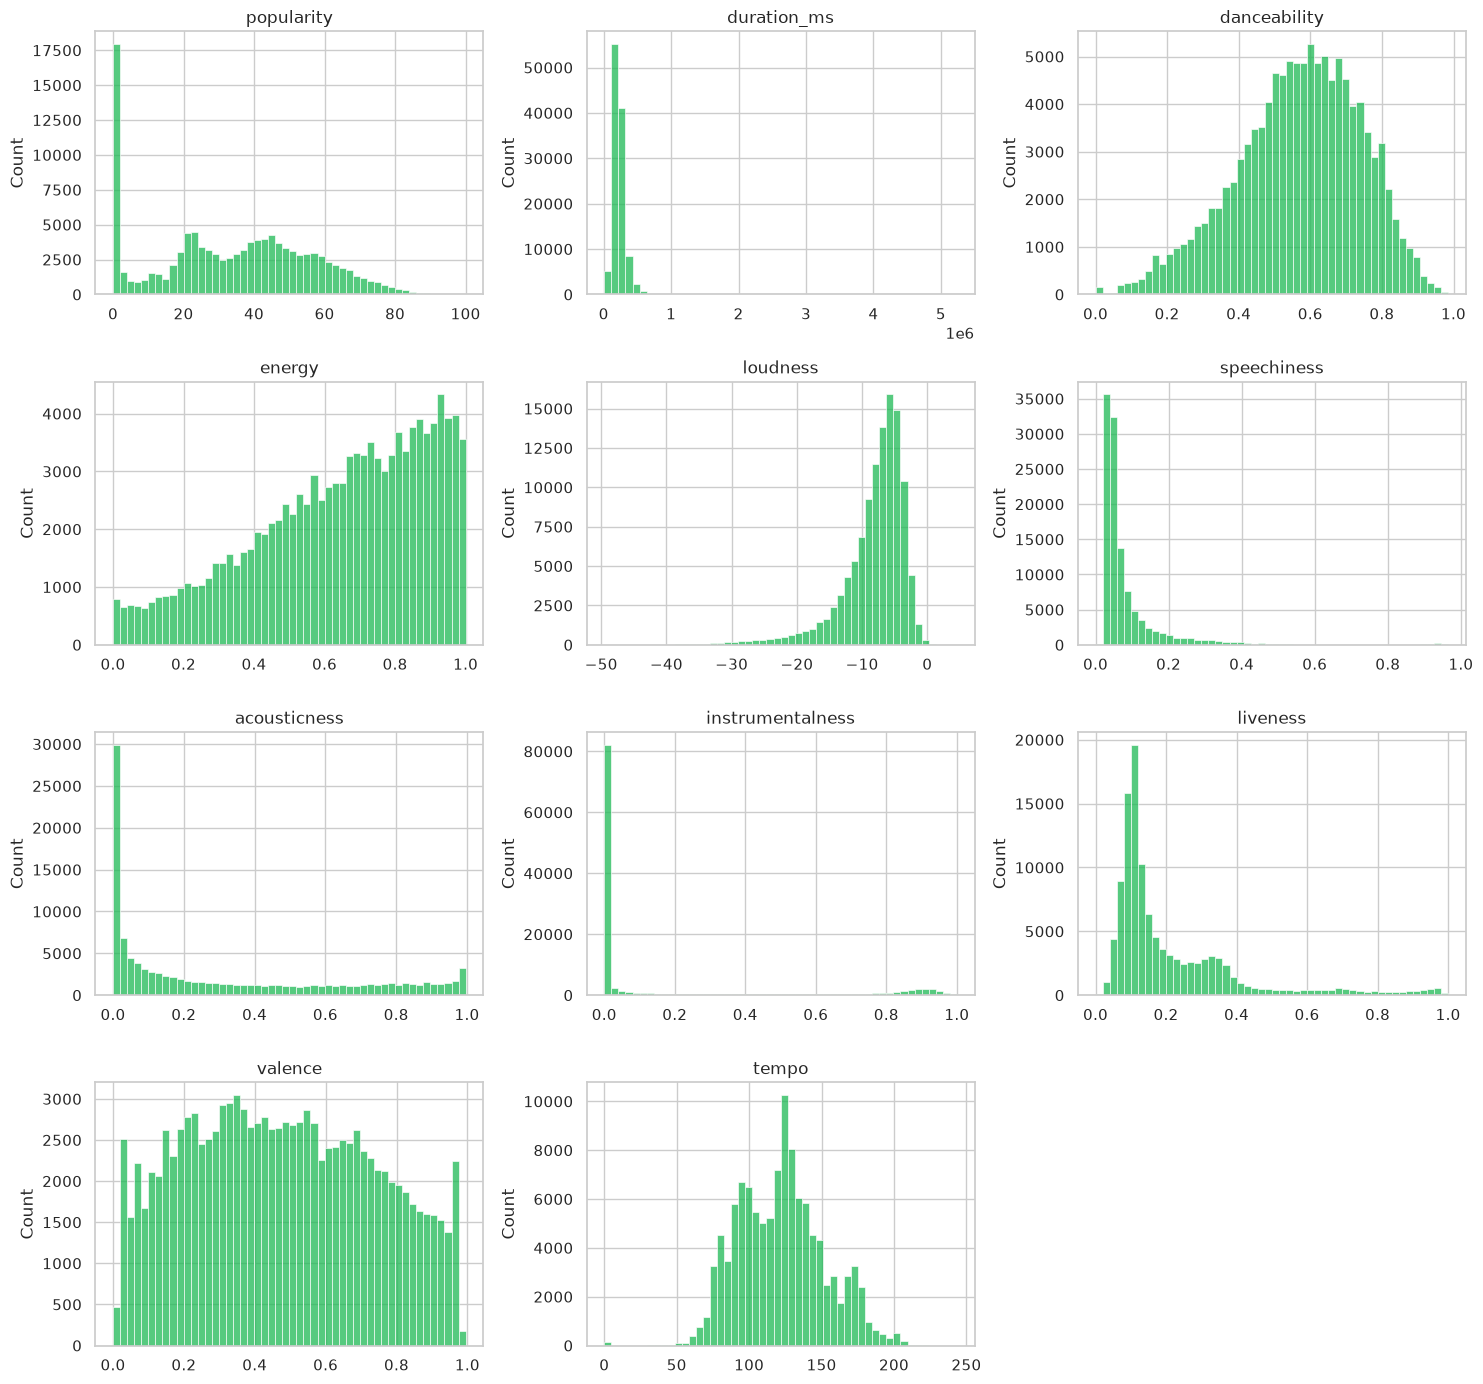

In [14]:
cols_numericas = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                   'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                   'valence', 'tempo']

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.histplot(df_clean[col], bins=50, ax=axes[i], color='#1DB954')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# remove o eixo vazio (11 colunas em grade de 12)
fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('/tmp/histogramas_passo3.png', dpi=110, bbox_inches='tight')
plt.show()

In [15]:
# Assimetria (skewness) de cada coluna: 0 = simétrica, positivo = cauda à direita, negativo = cauda à esquerda
df_clean[cols_numericas].skew().sort_values(ascending=False)

duration_ms         10.814577
speechiness          4.644570
liveness             2.105478
instrumentalness     1.737770
acousticness         0.730220
tempo                0.231604
valence              0.114774
popularity           0.042229
danceability        -0.400404
energy              -0.598550
loudness            -2.013340
dtype: float64

**Critério de interpretação do skew:** para classificar a magnitude da assimetria, é usada a regra de referência de Bulmer (1979), baseada no valor absoluto do skew:

| \|skew\| | Classificação |
|---|---|
| < 0,5 | Aproximadamente simétrica |
| 0,5 a 1 | Moderadamente assimétrica |
| ≥ 1 | Fortemente assimétrica |

*Nota metodológica:* existe também um teste estatístico formal de significância (skew dividido pelo erro-padrão, ≈ `√(6/n)` para amostras grandes). Com `n = 113.549`, esse erro-padrão é muito pequeno (~0,007), o que torna praticamente qualquer skew diferente de 0 "estatisticamente significativo" — por isso a regra de magnitude acima é o critério prático adotado aqui, não o teste de significância.

Reclassificando as 11 variáveis do Passo 3 por esse critério:

| Variável | Skew | Classificação |
|---|---|---|
| `duration_ms` | 10,81 | Fortemente assimétrica |
| `speechiness` | 4,64 | Fortemente assimétrica |
| `loudness` | -2,01 | Fortemente assimétrica |
| `liveness` | 2,11 | Fortemente assimétrica |
| `instrumentalness` | 1,74 | Fortemente assimétrica |
| `acousticness` | 0,73 | Moderadamente assimétrica |
| `energy` | -0,60 | Moderadamente assimétrica |
| `tempo` | 0,23 | Aproximadamente simétrica |
| `valence` | 0,11 | Aproximadamente simétrica |
| `popularity` | 0,04 | Aproximadamente simétrica |
| `danceability` | -0,40 | Aproximadamente simétrica |

**Correção de visualização:** o histograma de `duration_ms` ficou ilegível — o outlier de ~87 minutos (já identificado no Passo 1) esticou o eixo X a ponto de esconder a forma real da distribuição, que fica toda comprimida numa faixa muito pequena. A célula a seguir refaz esse gráfico limitando o eixo ao percentil 99 (sem remover nenhum dado do dataset, só ajustando o que é exibido).

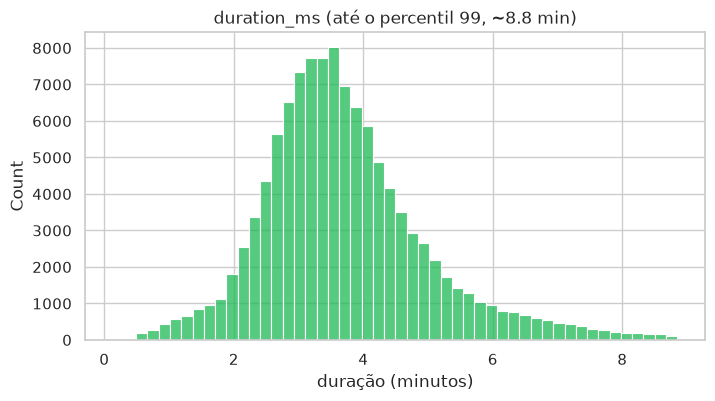

In [16]:
p99 = df_clean['duration_ms'].quantile(0.99)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean[df_clean['duration_ms'] <= p99]['duration_ms'] / 1000 / 60, bins=50, color='#1DB954')
plt.xlabel('duração (minutos)')
plt.title(f'duration_ms (até o percentil 99, ~{p99/1000/60:.1f} min)')
plt.savefig('/tmp/duration_zoom.png', dpi=110, bbox_inches='tight')
plt.show()

## Passo 4 — Variáveis categóricas e discretas

O Passo 3 cobriu as variáveis contínuas. Esta etapa olha as colunas que funcionam como **categorias**, não como escalas contínuas: `track_genre`, `key`, `mode`, `time_signature` e `explicit`. Para esse tipo de variável, o histograma não é a ferramenta certa — o gráfico apropriado é de **barras**, uma por categoria, sem a noção de "faixas contínuas" (*bins*) que os histogramas usam.

### 4.1 — Balanceamento de `track_genre`

A documentação oficial da fonte (Seção "Dicionário de dados") menciona **125 gêneros diferentes**. O resumo de discussão do grupo registrou a expectativa de **114 gêneros com exatamente 1.000 registros cada** — os dois números não batem, e isso precisa ser verificado diretamente nos dados, não assumido.

In [17]:
contagem_generos = df_clean['track_genre'].value_counts()

print("Número de gêneros distintos:", df_clean['track_genre'].nunique())
print()
print("Estatística da contagem por gênero:")
print(contagem_generos.describe())

Número de gêneros distintos: 114

Estatística da contagem por gênero:
count     114.000000
mean      996.043860
std        11.844412
min       904.000000
25%       998.000000
50%       999.000000
75%      1000.000000
max      1000.000000
Name: count, dtype: float64


**Resultado:** 114 gêneros distintos no arquivo real — não 125, como a documentação da fonte menciona. Mais um caso de divergência entre a documentação pública e os dados efetivamente entregues (mesmo padrão já visto com `time_signature`).

O balanceamento também não é mais perfeitamente uniforme após a limpeza: a mediana continua em 999–1000, mas o mínimo caiu para 904 — algum gênero específico perdeu bem mais registros que os outros durante a remoção de duplicatas exatas. A célula a seguir identifica esse(s) gênero(s), comparando a contagem original com a pós-limpeza.

In [18]:
contagem_original = df['track_genre'].value_counts()
contagem_limpa = df_clean['track_genre'].value_counts()

comparacao = pd.DataFrame({'original': contagem_original, 'apos_limpeza': contagem_limpa})
comparacao['removidos'] = comparacao['original'] - comparacao['apos_limpeza']
comparacao.sort_values('removidos', ascending=False).head(10)

,original,apos_limpeza,removidos
track_genre,,,
romance,1000,904,96
classical,1000,933,67
german,1000,963,37
dance,1000,965,35
honky-tonk,1000,981,19
iranian,1000,988,12
latin,1000,990,10
kids,1000,991,9
hip-hop,1000,991,9


### 4.2 — `key`, `mode`, `time_signature` e `explicit`

Diferente de `track_genre` (114 categorias), essas quatro colunas têm poucas categorias possíveis, o que permite visualizar todas de uma vez em gráficos de barra.

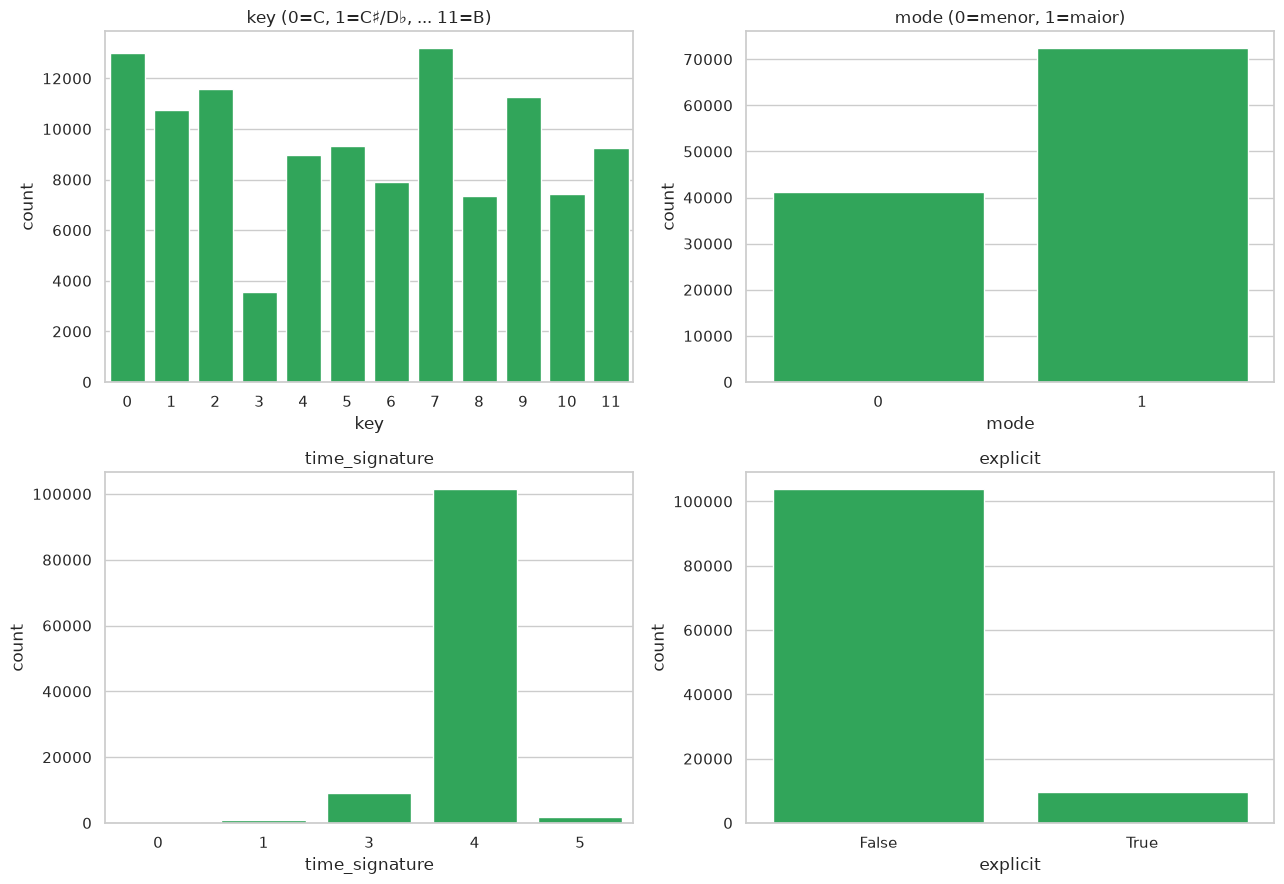

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

sns.countplot(x='key', data=df_clean, ax=axes[0,0], color='#1DB954')
axes[0,0].set_title('key (0=C, 1=C♯/D♭, ... 11=B)')

sns.countplot(x='mode', data=df_clean, ax=axes[0,1], color='#1DB954')
axes[0,1].set_title('mode (0=menor, 1=maior)')

sns.countplot(x='time_signature', data=df_clean, ax=axes[1,0], color='#1DB954')
axes[1,0].set_title('time_signature')

sns.countplot(x='explicit', data=df_clean, ax=axes[1,1], color='#1DB954')
axes[1,1].set_title('explicit')

plt.tight_layout()
plt.savefig('/tmp/categoricas_passo4.png', dpi=110, bbox_inches='tight')
plt.show()

**Resultado:**

- **`key`:** distribuição bastante desigual entre as 12 tonalidades — `C` (0) e `G` (7) são as mais comuns (~13.000 cada), `D♯/E♭` (3) é a mais rara (~3.600). Isso é coerente com teoria musical: C e G são tonalidades "amigáveis" para violão e piano, mais usadas na composição popular.
- **`mode`:** maioria em modo maior (1, ~72.000) sobre menor (0, ~41.000) — proporção de aproximadamente 64%/36%, compatível com a tendência geral de música popular favorecer tonalidade maior.
- **`time_signature`:** confirma visualmente o que já foi quantificado no Passo 2 — a esmagadora maioria é `4` (compasso 4/4, ~102.000), seguida de `3` (~9.000) e `5` (~1.800); as barras de `0` e `1` (163 e 973 linhas) aparecem, como esperado, quase imperceptíveis nessa escala.
- **`explicit`:** predominantemente `False` (~104.000) sobre `True` (~9.000), proporção de ~92%/8%. **Ressalva importante da documentação oficial:** `False` engloba tanto "confirmadamente sem conteúdo explícito" quanto "desconhecido" — os dois casos são indistinguíveis nesta coluna, então essa proporção de 8% é um piso, não necessariamente o valor real de faixas explícitas no catálogo.

### Conclusão do Passo 4

O dataset tem 114 gêneros (não 125, divergindo da documentação), quase balanceados após a limpeza (904–1.000 registros por gênero, com `romance` e `classical` mais afetados pela remoção de duplicatas). As variáveis categóricas discretas (`key`, `mode`, `time_signature`, `explicit`) têm distribuições desiguais mas musicalmente coerentes, sem novos problemas de qualidade — os únicos pontos de atenção (`time_signature` fora do intervalo documentado, `explicit` com ambiguidade em `False`) já estavam mapeados nos passos anteriores.

## Passo 5 — Relações entre variáveis

Os passos anteriores olharam cada variável isoladamente. Esta etapa responde à Pergunta 4 do EDA: **como as variáveis se relacionam entre si**.

### 5.1 — Matriz de correlação

A ferramenta usada é o **coeficiente de correlação de Pearson**, que mede o grau de relação **linear** entre duas variáveis numéricas, num intervalo de -1 a 1:

- **Próximo de +1:** quando uma variável sobe, a outra tende a subir junto (relação positiva forte).
- **Próximo de -1:** quando uma sobe, a outra tende a cair (relação negativa forte).
- **Próximo de 0:** não há relação linear detectável entre as duas (pode ainda existir relação não-linear, que o Pearson não captura).

**Limitação importante:** correlação mede associação, não causa — duas variáveis podem estar correlacionadas sem que uma cause a outra (podem ter uma causa comum, ou a relação pode ser coincidência estatística). Além disso, o Pearson só enxerga relações em linha reta; uma relação em formato de "U", por exemplo, pode dar correlação próxima de 0 mesmo havendo uma relação clara entre as variáveis.

A matriz é calculada sobre as colunas numéricas contínuas (`popularity` + as audio features); `key`, `mode`, `time_signature` e `explicit` ficam de fora por serem categóricas/discretas, onde o Pearson não é a ferramenta apropriada.

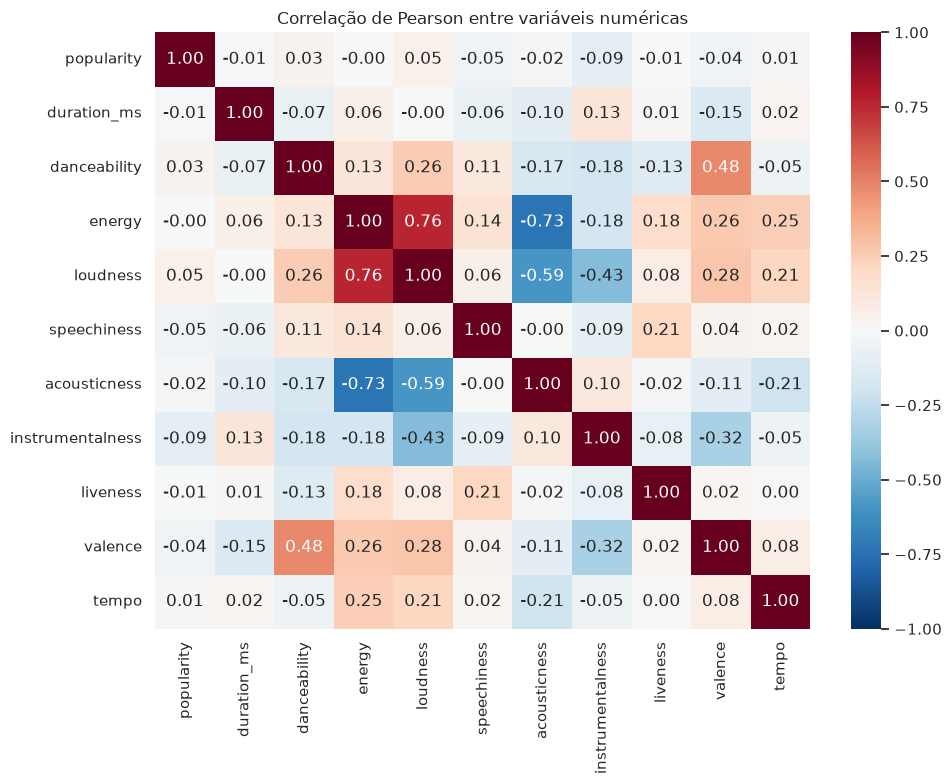

In [20]:
cols_correlacao = ['popularity', 'duration_ms', 'danceability', 'energy', 'loudness',
                    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
                    'valence', 'tempo']

matriz_corr = df_clean[cols_correlacao].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Correlação de Pearson entre variáveis numéricas')
plt.tight_layout()
plt.savefig('/tmp/heatmap_passo5.png', dpi=110, bbox_inches='tight')
plt.show()

**Resultado:**

- **`popularity` não apresenta correlação linear relevante com nenhuma audio feature** — todos os valores ficam entre -0,09 e 0,05, essencialmente zero. Nenhuma característica sonora isolada explica popularidade de forma linear neste dataset.
- **Par mais correlacionado: `energy` × `loudness` = 0,76** (forte, positiva) — faixas mais energéticas tendem a ser mastigadas/mixadas mais altas.
- **`energy` × `acousticness` = -0,73** (forte, negativa) — faixas acústicas tendem a ter menos energia percebida.
- **`loudness` × `acousticness` = -0,59** (moderada, negativa) — mesma lógica: acústico tende a ser mais baixo em volume.
- **`danceability` × `valence` = 0,48** (moderada, positiva) — faixas mais dançantes tendem a soar mais "positivas/alegres".
- **`instrumentalness` × `loudness` = -0,43** e **`instrumentalness` × `valence` = -0,32** (moderadas, negativas) — faixas instrumentais tendem a ser um pouco mais baixas e menos "alegres" que faixas com vocal.
- **`duration_ms` não tem correlação relevante com nenhuma outra variável** (tudo abaixo de 0,15 em módulo) — a duração de uma faixa não se relaciona linearmente com suas características sonoras.

O padrão geral: existe um "triângulo" coerente entre `energy`, `loudness` e `acousticness` (tudo que aumenta energia/volume tende a reduzir acusticidade, e vice-versa) — é o par de relações mais forte do dataset. Fora desse triângulo, a maioria das correlações é fraca, reforçando que as audio features capturam dimensões relativamente independentes umas das outras.

### 5.2 — Comparação entre gêneros

Com 114 gêneros, comparar todos de uma vez tornaria o gráfico ilegível. Foi selecionado um subconjunto de **8 gêneros contrastantes**, cobrindo o espectro de energia/atmosfera sonora observado no dataset: `sleep` e `classical` (baixa energia, já investigados no Passo 2 pela ausência de ritmo detectável), `acoustic` e `jazz` (intermediários, ligados a `acousticness`), `pop` e `hip-hop` (mainstream, contrastando produção e `speechiness`), `edm` e `death-metal` (alta energia/volume).

Os boxplots comparam 4 audio features que se destacaram na matriz de correlação do Passo 5.1: `energy`, `acousticness` (par fortemente correlacionado, -0,73), `danceability` e `valence` (par moderadamente correlacionado, 0,48) — a ideia é checar visualmente se essas relações se sustentam quando os dados são separados por gênero.

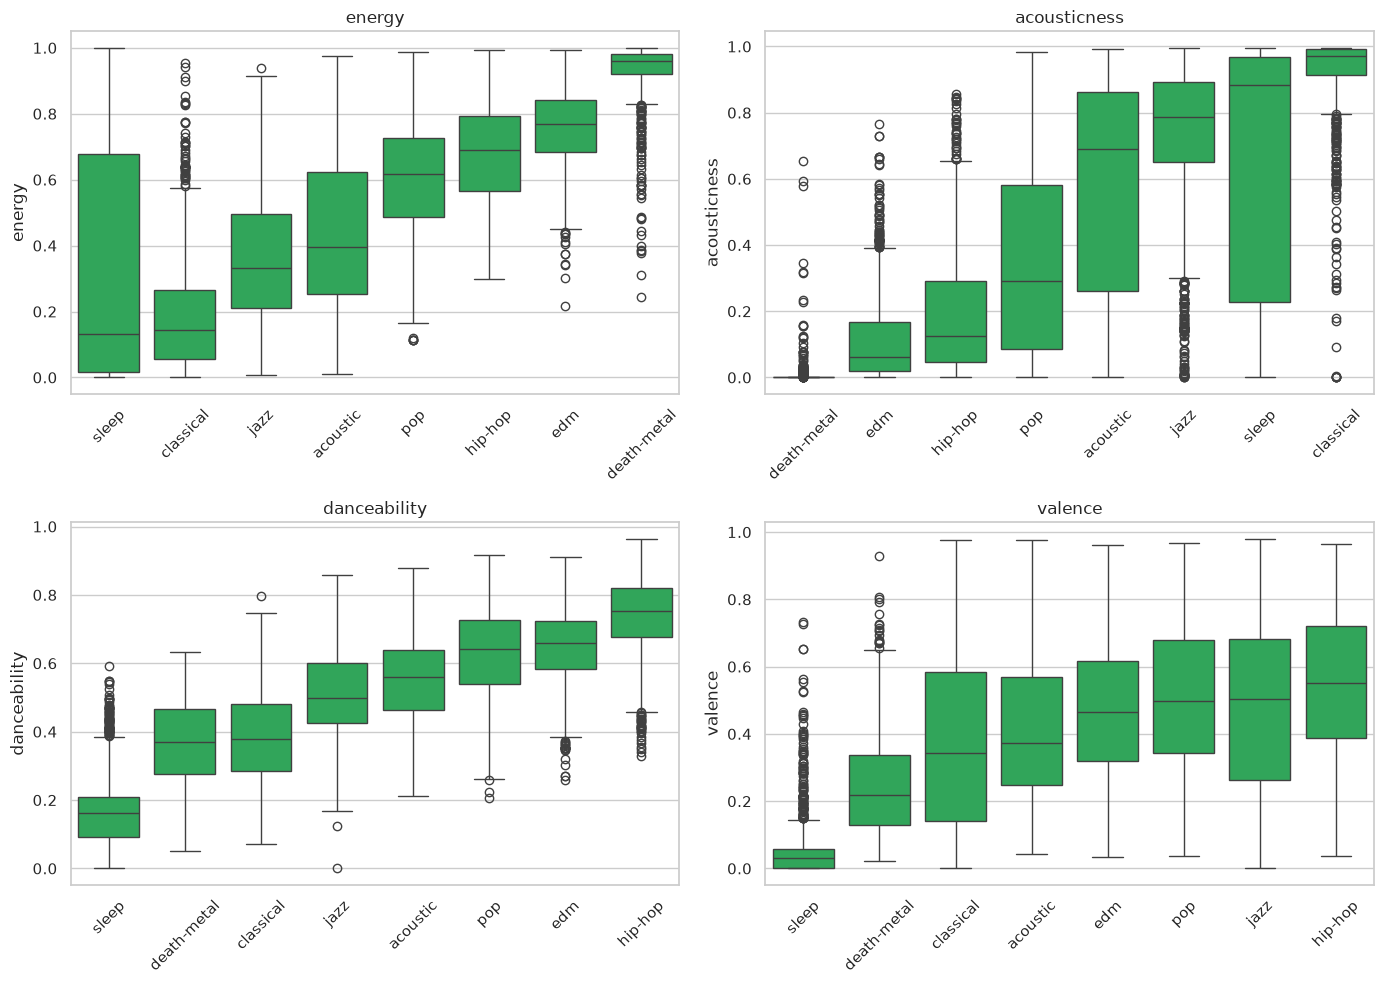

In [21]:
generos_selecionados = ['sleep', 'classical', 'acoustic', 'jazz', 'pop', 'hip-hop', 'edm', 'death-metal']
df_generos = df_clean[df_clean['track_genre'].isin(generos_selecionados)]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features_para_comparar = ['energy', 'acousticness', 'danceability', 'valence']

for ax, feat in zip(axes.flatten(), features_para_comparar):
    ordem = df_generos.groupby('track_genre')[feat].median().sort_values().index
    sns.boxplot(data=df_generos, x='track_genre', y=feat, order=ordem, ax=ax, color='#1DB954')
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/tmp/boxplots_generos_passo5.png', dpi=110, bbox_inches='tight')
plt.show()

**Resultado:**

- **`energy` × `acousticness` são espelhos quase perfeitos entre gêneros:** `death-metal` tem a maior energia (mediana ~0,95) e a menor acusticidade (mediana ~0); `classical` e `sleep` têm o padrão oposto (energia ~0,13-0,15, acusticidade ~0,85-0,90). Essa ordem invertida confirma visualmente, gênero a gênero, a correlação de -0,73 encontrada no Passo 5.1.
- **`danceability` e `energy` não seguem a mesma ordem entre gêneros:** `death-metal` e `classical` têm dançabilidade parecida (~0,35-0,38) apesar de estarem em extremos opostos de energia — evidência concreta, em nível de gênero, de que essas duas variáveis são bem menos correlacionadas entre si (0,13 no Passo 5.1) do que energy/acousticness.
- **`valence` tem a variação mais suave entre gêneros:** `sleep` se destaca como o mais "triste/neutro" (mediana ~0,05), enquanto `hip-hop` é o mais "positivo" (mediana ~0,55) — mas a diferença entre a maioria dos outros gêneros é pequena, sem separações tão nítidas quanto em `energy`/`acousticness`.
- **`death-metal` tem valence baixa apesar de energia alta** (mediana ~0,22) — energia e positividade não andam juntas: o gênero é energético mas soa "sombrio", não "alegre". Isso reforça que `energy` e `valence` capturam dimensões perceptualmente diferentes (intensidade vs. tom emocional), mesmo tendo correlação moderada positiva (0,26) no geral.

### Conclusão do Passo 5

A matriz de correlação (5.1) e os boxplots por gênero (5.2) são consistentes entre si: a relação mais forte e estável do dataset é o eixo `energy`/`loudness`/`acousticness`, visível tanto na base inteira quanto gênero a gênero. `popularity`, por outro lado, permanece sem relação linear clara com nenhuma audio feature — esse ponto seguirá em aberto até a fase de formulação/teste de hipóteses.

### 5.3 — Estrutura de estilos: os 114 gêneros formam "famílias" naturais?

Esta subseção nasce de guiding questions específicas sobre um possível recurso de produto (seleção de "estilo" num chat de recomendação): os 114 gêneros do dataset se agrupam em famílias de estilo mais amplas? Dentro de um gênero, as músicas realmente soam parecidas? Gêneros diferentes com áudio parecido deveriam ser tratados como relacionados?

A técnica usada é **clustering hierárquico aglomerativo** sobre a média das 9 audio features contínuas (`danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`, `tempo`), uma linha por gênero (114 linhas). As features são padronizadas (z-score) antes do clustering, porque estão em escalas muito diferentes (`loudness` em dB, `tempo` em BPM, o resto de 0 a 1) — sem padronizar, `tempo`/`loudness` dominariam a distância só pela escala, não pela variação real.

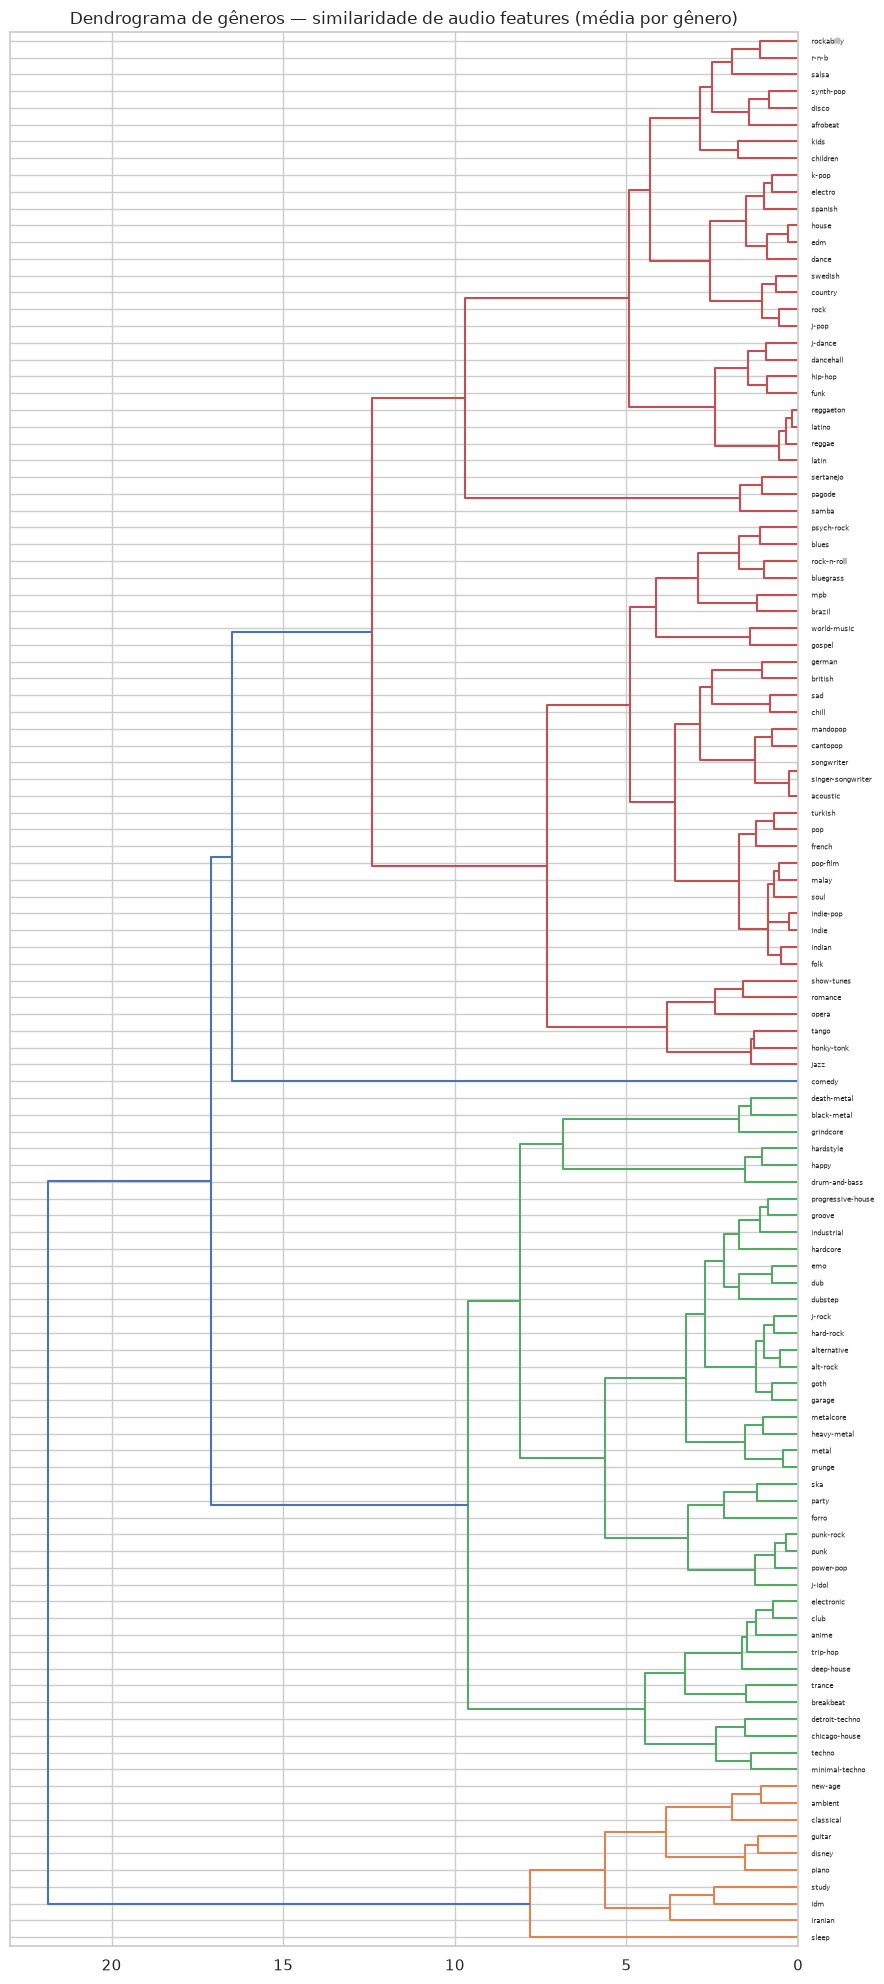

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

features = ['danceability','energy','loudness','speechiness','acousticness',
            'instrumentalness','liveness','valence','tempo']

genero_medias = df_clean.groupby('track_genre')[features].mean()
X = StandardScaler().fit_transform(genero_medias)
Z = linkage(X, method='ward')

plt.figure(figsize=(9, 20))
dendrogram(Z, labels=genero_medias.index.tolist(), orientation='left', color_threshold=13)
plt.title('Dendrograma de gêneros — similaridade de audio features (média por gênero)')
plt.tight_layout()
plt.savefig('/tmp/dendrograma_generos_nb.png', dpi=110, bbox_inches='tight')
plt.show()

**Leitura do dendrograma:** existem agrupamentos claramente coerentes — gêneros brasileiros (`sertanejo`, `pagode`, `samba`) formam um ramo isolado; metal/punk/rock formam um grande ramo compartilhado; música eletrônica de pista (`techno`, `house`, `trance`, `chicago-house`) forma outro; e um pequeno ramo bem definido reúne `new-age`, `ambient`, `classical`, `guitar`, `disney`, `piano`, `study`, `idm`, `iranian`, `sleep` — justamente os gêneros "calmos/instrumentais" mais próximos do conceito de "lofi" que o dataset não rotula diretamente.

Ao mesmo tempo, o agrupamento não é perfeito: `comedy` fica isolado sozinho (ramo próprio, ligado aos demais só na raiz da árvore — áudio muito atípico, dominado por fala), e existe um ramo grande e heterogêneo que mistura `pop`, `jazz`, `opera`, `blues` e `folk` — gêneros perceptualmente bem diferentes entre si, mas que não se separam claramente usando só estas 9 audio features.

A célula a seguir corta a árvore em 8 grupos e lista a composição de cada um, para checar objetivamente essa leitura visual.

In [23]:
clusters = fcluster(Z, t=8, criterion='maxclust')
familias = pd.Series(clusters, index=genero_medias.index, name='cluster')

for c in sorted(familias.unique()):
    membros = familias[familias == c].index.tolist()
    print(f"Cluster {c} ({len(membros)} gêneros): {membros}")

Cluster 1 (10 gêneros): ['ambient', 'classical', 'disney', 'guitar', 'idm', 'iranian', 'new-age', 'piano', 'sleep', 'study']
Cluster 2 (11 gêneros): ['anime', 'breakbeat', 'chicago-house', 'club', 'deep-house', 'detroit-techno', 'electronic', 'minimal-techno', 'techno', 'trance', 'trip-hop']
Cluster 3 (24 gêneros): ['alt-rock', 'alternative', 'dub', 'dubstep', 'emo', 'forro', 'garage', 'goth', 'groove', 'grunge', 'hard-rock', 'hardcore', 'heavy-metal', 'industrial', 'j-idol', 'j-rock', 'metal', 'metalcore', 'party', 'power-pop', 'progressive-house', 'punk', 'punk-rock', 'ska']
Cluster 4 (6 gêneros): ['black-metal', 'death-metal', 'drum-and-bass', 'grindcore', 'happy', 'hardstyle']
Cluster 5 (33 gêneros): ['acoustic', 'bluegrass', 'blues', 'brazil', 'british', 'cantopop', 'chill', 'folk', 'french', 'german', 'gospel', 'honky-tonk', 'indian', 'indie', 'indie-pop', 'jazz', 'malay', 'mandopop', 'mpb', 'opera', 'pop', 'pop-film', 'psych-rock', 'rock-n-roll', 'romance', 'sad', 'show-tunes', 

**Resultado:** os 8 clusters confirmam a leitura do dendrograma — grupos musicalmente coerentes (metal/punk, eletrônica de pista, gêneros brasileiros, `comedy` isolado sozinho) convivem com um cluster grande e heterogêneo (33 gêneros, incluindo `pop`, `jazz`, `opera`, `blues`, `folk`) onde a separação por áudio é fraca. **Resposta à guiding question:** sim, existe uma estrutura de família parcial e genuína — mas está longe de ser limpa o suficiente para substituir os 114 rótulos por um punhado de categorias sem perda relevante de informação, pelo menos usando só estas 9 features.

### Homogeneidade interna de cada gênero

A pergunta seguinte é complementar: mesmo dentro de um único gênero, as músicas são parecidas entre si, ou o rótulo esconde bastante variação interna? Isso é medido comparando o desvio-padrão de cada feature **dentro de cada gênero** contra o desvio-padrão da mesma feature **no dataset inteiro** — uma razão próxima de 0 indica um gênero muito mais homogêneo que a média geral; próxima de 1 (ou acima), um gênero tão ou mais variado internamente que o dataset como um todo.

In [24]:
std_global = df_clean[features].std()
std_por_genero = df_clean.groupby('track_genre')[features].std()
razao = (std_por_genero / std_global).mean(axis=1).sort_values()

print("Mediana da razão (todos os 114 gêneros):", round(razao.median(), 3))
print()
print("Gêneros mais homogêneos (razão mais baixa):")
print(razao.head(5))
print()
print("Gêneros menos homogêneos (razão mais alta, tão variados quanto o dataset inteiro):")
print(razao.tail(5))

Mediana da razão (todos os 114 gêneros): 0.728

Gêneros mais homogêneos (razão mais baixa):
track_genre
party        0.547054
house        0.551254
edm          0.570380
metalcore    0.575116
dance        0.579733
dtype: float64

Gêneros menos homogêneos (razão mais alta, tão variados quanto o dataset inteiro):
track_genre
comedy     1.011819
piano      1.049532
iranian    1.083417
sleep      1.123674
german     1.155103
dtype: float64


**Resposta à guiding question:** o gênero rotulado esconde variação real, mas não completamente. A mediana da razão é **0,73** — em média, um gênero é cerca de 27% menos variado internamente que o dataset como um todo, uma redução moderada, não drástica. Alguns gêneros são bem mais fechados (`party`, `house`, `edm`, `metalcore`, `dance`, razão ~0,55) — bom sinal para uma recomendação baseada em gênero. Outros (`sleep`, `german`, `iranian`, `piano`, `comedy`) têm razão **acima de 1** — são tão ou mais heterogêneos internamente que o dataset inteiro, ou seja, o rótulo de gênero pouco reduz a incerteza sobre como a música realmente soa.

### Faixas com múltiplos gêneros: os pares fazem sentido musical?

Retomando o achado do Passo 2.2 (23.809 linhas com `track_id` repetido em gêneros diferentes): quando uma música pertence a mais de um gênero, os gêneros envolvidos costumam ser musicalmente próximos (o que ajudaria uma recomendação por estilo) ou são combinações arbitrárias (o que atrapalharia)? A célula a seguir lista os pares de gênero que mais co-ocorrem na mesma faixa.

In [25]:
from itertools import combinations
from collections import Counter

multi = df_clean.groupby('track_id')['track_genre'].agg(list)
multi = multi[multi.apply(len) > 1]

pares = Counter()
for generos in multi:
    for a, b in combinations(sorted(set(generos)), 2):
        pares[(a, b)] += 1

pd.DataFrame(pares.most_common(15), columns=['par_de_generos', 'ocorrencias'])

,par_de_generos,ocorrencias
0,"(singer-songwriter, songwriter)",1000
1,"(reggae, reggaeton)",804
2,"(latino, reggaeton)",738
3,"(dub, dubstep)",727
4,"(punk, punk-rock)",628
5,"(edm, house)",624
6,"(latino, reggae)",616
7,"(alt-rock, alternative)",592
8,"(latin, latino)",588
9,"(indie, indie-pop)",579


**Resultado:** os 15 pares mais comuns fazem sentido musical quase sem exceção — `reggae`+`reggaeton`, `dub`+`dubstep`, `punk`+`punk-rock`, `edm`+`house`, `alt-rock`+`alternative`, `indie`+`indie-pop`, `latin`+`latino`+`reggaeton`/`reggae` (a família latina inteira aparece interligada). O par mais frequente, `singer-songwriter`+`songwriter` (1.000 ocorrências — todas as faixas de um dos dois gêneros), sugere que esses dois rótulos são quase sinônimos no catálogo do Spotify. **Resposta à guiding question:** a multi-rotulagem de gênero ajuda mais do que atrapalha — reflete relações reais de subgênero/gênero-adjacente, não combinações arbitrárias.

### Popularidade dos gêneros "lofi-like" — existe viés contra estilos de nicho?

Por fim, a guiding question sobre viés: estilos populares dominam e "sufocam" estilos de nicho como lofi? Como o dataset **não tem um gênero chamado `lofi`**, a pergunta é respondida usando os gêneros mais próximos desse conceito (identificados no cluster "calmo/instrumental" do dendrograma): `chill`, `study`, `ambient`, `acoustic`, `sleep`, `piano`, `singer-songwriter`.

In [26]:
print("'lofi' existe como rótulo de gênero?", 'lofi' in df_clean['track_genre'].unique())
print()

lofi_like = ['chill', 'study', 'ambient', 'acoustic', 'sleep', 'piano', 'singer-songwriter']
pop_por_genero = df_clean.groupby('track_genre')['popularity'].median().sort_values(ascending=False)
rank = pop_por_genero.rank(ascending=False).astype(int)

pd.DataFrame({'popularidade_mediana': pop_por_genero[lofi_like],
              'posicao_no_ranking_de_114': rank[lofi_like]}).sort_values('posicao_no_ranking_de_114')

'lofi' existe como rótulo de gênero? False



,popularidade_mediana,posicao_no_ranking_de_114
track_genre,,
chill,57.0,5
ambient,50.0,16
piano,50.0,16
acoustic,47.0,24
singer-songwriter,43.0,34
sleep,35.0,61
study,28.0,72


**Resultado:** confirmado — **"lofi" não existe como rótulo de gênero neste dataset** (114 gêneros, nenhum chamado `lofi`); qualquer recurso de produto que ofereça "lofi" como opção precisaria mapear isso para um gênero substituto (`chill` é o candidato mais próximo) ou combinar vários gêneros calmos/instrumentais.

Quanto ao viés: os dados **não confirmam** a hipótese de que estilos "lofi-like" sejam sistematicamente sufocados por estilos populares — o quadro é misto. `chill` está entre os gêneros **mais populares do dataset inteiro** (5º de 114); `ambient` e `piano` ficam bem acima da mediana (16º); mas `study` (72º) e `sleep` (61º) de fato ficam abaixo do meio da tabela. Não é um viés uniforme contra "tudo que soa lofi" — é específico de subestilo: `chill` (mais próximo de uma "playlist de trabalho/relaxamento" mainstream) performa bem; `study`/`sleep` (mais nichados, função utilitária específica) performam pior.

### Conclusão do Passo 5.3

Os 114 gêneros têm uma estrutura de família parcial e genuína (confirmada por clustering hierárquico e por co-ocorrência musicalmente coerente entre gêneros multi-rotulados), mas a redução para poucas categorias tem custo real: em média um gênero só é ~27% mais homogêneo que o dataset inteiro, e alguns gêneros centrais para um caso de uso "lofi" (`sleep`, `study`) estão entre os mais heterogêneos e menos populares do catálogo. Qualquer agrupamento de estilos para uma interface de usuário precisaria ser validado com essas limitações em mente, não assumido como direto.

### 5.4 — Clustering ao nível de faixa vs. rótulo de gênero

O Passo 5.3 fez clustering sobre a **média de cada gênero** (114 pontos, um por gênero) — uma visão agregada que suaviza a variação interna. Esta subseção responde uma pergunta mais exigente: agrupando **faixas individuais** (113.549 pontos) pelas mesmas 9 audio features, os clusters resultantes recuperam a estrutura de `track_genre`, ou descobrem uma organização diferente?

Usa-se **K-Means** (features padronizadas, `K=8` — mesmo número de grupos do Passo 5.3, para permitir comparação direta) e dois índices de concordância entre o agrupamento encontrado e os rótulos de gênero originais: **Adjusted Rand Index (ARI)** e **Normalized Mutual Information (NMI)**, ambos 0 (nenhuma relação) a 1 (concordância perfeita).

In [27]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

X_faixas = StandardScaler().fit_transform(df_clean[features])
km = KMeans(n_clusters=8, random_state=42, n_init=10).fit(X_faixas)
df_clean['cluster_kmeans'] = km.labels_

ari = adjusted_rand_score(df_clean['track_genre'], df_clean['cluster_kmeans'])
nmi = normalized_mutual_info_score(df_clean['track_genre'], df_clean['cluster_kmeans'])
print(f"Adjusted Rand Index (K-Means vs track_genre): {ari:.4f}")
print(f"Normalized Mutual Information: {nmi:.4f}")
print()

for c in sorted(df_clean['cluster_kmeans'].unique()):
    sub = df_clean[df_clean['cluster_kmeans'] == c]
    top = sub['track_genre'].value_counts(normalize=True).head(3)
    print(f"Cluster {c} (n={len(sub)}, top gênero={top.index[0]} com {top.iloc[0]*100:.1f}%)")

Adjusted Rand Index (K-Means vs track_genre): 0.0170
Normalized Mutual Information: 0.1714

Cluster 0 (n=11554, top gênero=minimal-techno com 7.4%)
Cluster 1 (n=22142, top gênero=tango com 3.4%)
Cluster 2 (n=32722, top gênero=salsa com 2.4%)
Cluster 3 (n=24761, top gênero=metalcore com 3.4%)
Cluster 4 (n=6778, top gênero=j-dance com 7.7%)
Cluster 5 (n=7260, top gênero=new-age com 10.7%)
Cluster 6 (n=7395, top gênero=pagode com 6.8%)
Cluster 7 (n=937, top gênero=comedy com 85.2%)


**Resultado:** o ARI é **0,017** — essencialmente zero, indicando que o agrupamento por K-Means ao nível de faixa individual **não recupera** a estrutura de `track_genre`. O NMI é **0,17**, fraco a moderado — existe algum compartilhamento de informação, mas longe de uma correspondência forte. A maioria dos clusters é uma mistura de dezenas de gêneros sem nenhum claramente dominante (ex: cluster 2, com 32.722 faixas, tem como "gênero mais comum" apenas 2,4% de participação). Duas exceções confirmam o padrão já visto: o cluster dominado por `comedy` (85,2% de pureza — fala tem uma assinatura acústica muito distinta) e um cluster que reúne majoritariamente a família `new-age`/`sleep`/`classical`/`ambient`/`piano` (mesma família "calma/instrumental" do Passo 5.3, ainda que sem um único gênero dominante).

**Isso nuancia o Passo 5.3, não o contradiz:** a média por gênero mostrava famílias coerentes porque a média suaviza a variação interna; ao nível de faixa individual, essa variação interna é grande o suficiente para que a maioria das faixas de gêneros diferentes se misture livremente no espaço de audio features. **Resposta à guiding question:** clustering (K-Means) sobre audio features não corresponde bem aos 114 rótulos de gênero individualmente — funciona para separar extremos muito distintos (fala vs. música, calmo vs. energético), mas não recupera as fronteiras de gênero de forma geral.

### Quais audio features mais diferenciam gênero?

A pergunta complementar: quais das 9 audio features (mais `key`, `mode`, `time_signature`) mais contribuem para diferenciar um gênero do outro? A métrica é o **eta ao quadrado (η²)** de uma ANOVA de um fator (gênero como fator): a fração da variância total de cada feature que é "explicada" pela diferença entre médias de gênero — 0 = gênero não explica nada da variação; 1 = toda a variação da feature é entre gêneros, nenhuma dentro deles.

In [28]:
from scipy.stats import f_oneway

todas_features = features + ['key', 'time_signature', 'mode']
resultado_eta = {}

for feat in todas_features:
    grand_mean = df_clean[feat].mean()
    ss_between = sum(len(g)*(g[feat].mean()-grand_mean)**2 for _, g in df_clean.groupby('track_genre'))
    ss_total = ((df_clean[feat]-grand_mean)**2).sum()
    resultado_eta[feat] = ss_between / ss_total

pd.Series(resultado_eta, name='eta_squared').sort_values(ascending=False)

acousticness        0.485314
energy              0.453214
instrumentalness    0.451713
loudness            0.448827
speechiness         0.441487
danceability        0.414286
valence             0.304608
liveness            0.151918
tempo               0.085058
time_signature      0.067289
mode                0.062998
key                 0.005239
Name: eta_squared, dtype: float64

**Resultado:** `acousticness` (η²=0,49), `energy` (0,45), `instrumentalness` (0,45), `loudness` (0,45), `speechiness` (0,44) e `danceability` (0,41) são as features mais discriminativas — cada uma sozinha explica ~41 a 49% da variância entre gêneros. `valence` tem poder moderado (0,30). `liveness` e `tempo` são fracas (0,15 e 0,09). **`key` é essencialmente inútil para diferenciar gênero (η²=0,005)** — praticamente toda sua variação é dentro dos gêneros, não entre eles; `mode` e `time_signature` também são fracas (~0,06-0,07).

**Resposta à guiding question:** confirmado quantitativamente — `energy` e `acousticness` (junto com `instrumentalness`, `loudness`, `speechiness`, `danceability`) de fato carregam a maior parte do poder de diferenciar estilo; `key` e `time_signature` contribuem muito pouco, como intuído na pergunta original.

### Conclusão do Passo 5.4

Individualmente, faixas de gêneros diferentes se misturam bastante no espaço de audio features (K-Means não recupera `track_genre`, ARI≈0) — mas um subconjunto de 6 features (`acousticness`, `energy`, `instrumentalness`, `loudness`, `speechiness`, `danceability`) concentra a maior parte do poder discriminativo que existe. Isso é relevante para qualquer decisão futura de modelagem: usar as 9-12 features com peso igual dilui o sinal real com o ruído de `key`/`mode`/`time_signature`, que quase não ajudam a diferenciar estilo.

## Artefato final — dataset limpo para as próximas fases

O `df_clean` resultante deste EDA é salvo como artefato reutilizável, para que a fase de modelagem (Fase 2 do plano em `../docs/planejamentoModelo.md`) não precise duplicar a lógica de limpeza documentada nos Passos 1-2.

In [29]:
df_clean.to_parquet('df_clean.parquet')
print(f"Salvo: entregas/df_clean.parquet ({len(df_clean)} linhas, {df_clean.shape[1]} colunas)")

Salvo: entregas/df_clean.parquet (113549 linhas, 21 colunas)
